In [1]:
import matplotlib.pyplot as plt

import hypernetx as hnx
from hypernetx.drawing.temporal import temporal_shortest_path, encode_path

# Temporal Hypergraph Paths
(or the easiest/fastest way to ditch Fluffy)

This tutorial explores the use of temporal hypergraph shortest paths. The notebook is motivated by Alice seeking to find pet care for her beloved cat, Fluffy so that Alice can take an extended vacation. Alice and her friends have a strict schedule for the week that is known/planned ahead for the week. None of them are willing to deviate from their schedule and simply pick up Fluffy from Alice or each other. Instead, Alice must try to find a way to get Fluffy to Bob (who has agreed to care for Fluffy long term) by handing off Fluffy from friend to friend until Fluffy reaches Bob.

Alice wants to consder two possible types of solutions:
1. The *shortest path*: how to get Fluffly to Bob with the *fewest handoffs* (because Fluffy does not enjoy being handed off), and
2. The *quickest path*: how to get Fluffy to Bob the *soonest* (because Alice can only leave for Vacation once Fluffy is safely with Bob)

We consider a hypergraph *H* where the nodes consist of Alice together with her friends and the hyper edges consist of the events where Alice or any of her friends interact. This hypergraph is constructed below. For simplicity, one event occurs per week day, and events (hyper edges) are numbered 0 - 5.

In [26]:
events = {
    0: ['Chad', 'Alice'],
    1: ['Alice', 'Erin'],
    2: ['Devon', 'Chad', 'James'],
    3: ['Erin', 'Frank', 'Greg', 'Devon'],
    4: ['Frank', 'Greg', 'Bob', 'Erin', 'Devon'],
    5: ['Alice', 'Harry', 'Bob'],
}

events = {
    0: ['Chad', 'Alice'],
    1: ['Alice', 'Erin'],
    2: ['Devon', 'Chad'],
    3: ['Erin', 'Devon'],
    4: ['Bob', 'Erin', 'Devon'],
    5: ['Alice', 'Bob'],
}

event_names = [
    'Work\nMon',
    'Gym\nTue',
    'Work\nWed',
    'Park\nThu',
    'Party\nFri',
    'Brunch\nSat',
]

edge_order = sorted(events)

H = hnx.Hypergraph(events)


## Solutions
The example below computes both solutions. It relies on `hypernetx.drawing.temporal.temporal_shortest_path` to compute each solution. Then the hypergraph is visualized as a storyline using `hypernetx.draw_incidence_storyline` and the path is highlighted using `hypernetx.drawing.temporal.encode_path`. We will discuss the definitions and details of the solution furhter on in the notebook.

### Storyline visualization for temporal hypergraphs
The storyline visualizations are intended for drawing edge-ordered hypergraphs, like we have in our scenario. Because these visualizations can also encode data onto the incidences and segments, they are ideal for explaining the solutions to our temporal hypergraph shortest path problem. In these visualizations, nodes are drawn as thin horizontal lines and hyper edges are drawn as thick vertical rounded rectangles. Each edge is assigned a unique x-coordinate as defined by the edge order provided to the visualization. Incidences are drawn as circles where the line for a node and an edge intersect.

The y-coordinates of nodes are optimized to reduce the clutter in the visualization such as unnecessary node bends, node-node and node-edge crossings. A node may cross an edge in the drawing even if that node is not a member of that edge. In this case, no circle is drawn at that location because that incidence is not in the hypergraph. Nodes are allowed to bend, and more than one node may occupy the same y-coordinate at different times.

### Encoding the optimal path in the visualization
Temporal hypergraph paths are shown using the storyline visualization as well. The starting and ending incidence of the path is filled with red, and the intermediate nodes are filled with black (the remaining nodes are not filled/white). The node portion of the path is thicker, and the edge portion of the path is filled with lightgray.

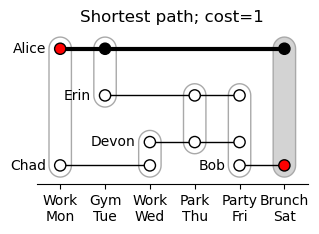

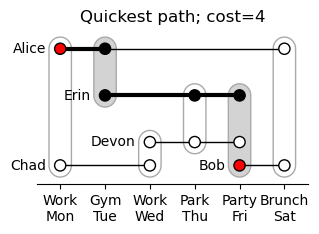

In [72]:
reload(temporal)

def solve_and_draw_path(H, edge_order, source, target, edge_labels=None, **kwargs):
    plt.figure()

    cost, path = temporal.temporal_shortest_path(
        H, source, target,
        edge_order=edge_order,
        **kwargs,
    )

    hnx.draw_incidence_storyline(
        H,
        edge_order=edge_order,
        edge_labels=edge_labels,
        layout_kwargs=dict(allow_edge_crossings=False),
        **temporal.encode_path(path)
    )

    return cost, path

kwargs = dict(
    H=H,
    edge_order=edge_order,
    source=(0, 'Alice'),
    target='Bob',
    edge_labels=event_names
)

cost, path = solve_and_draw_path(**kwargs, weight_by_time=False)
plt.title(f'Shortest path; cost={cost}')

cost, path = solve_and_draw_path(**kwargs, weight_by_time=True)
plt.title(f'Quickest path; cost={cost}');

### Discussion of competing solutions
This reveals two different solutions for Alice:
1. The shortest path has Alice keeping Fluffy until Brunch on Saturday, where she gives Fluffy to Bob. This has a cost of 1 handoff but requires 5 days.
2. The quickest path has Alice giving Fluffy to Erin at the Gym on Tuesday, then Erin giving Fluffy to Bob at the Party on Friday. This a cost of 4 days, but requires 2 handoffs.


## Details
First, let's take a look at how the path is modeled. We'll print out the path that was found above for solution #2.

In [4]:
path

[(0, 'Alice'), (1, 'Alice'), (1, 'Erin'), (3, 'Erin'), (4, 'Erin'), (4, 'Bob')]

### Definitions
We have chosen to represent the hypergraph path as a sequence of tuples. Each tuple represents an incidence *(e, v)*, i.e. the vertex *v* is a member of the hyper edge *e*. The `temporal_shortest_path` algorithm outputs sequences that are both **feasible** and **proper**.
* A **feasible path** is a path where every tuple is an incidence in *H* and the tuples are ordered by the given edge order. Additionally, adjacent tuples can differ by only the hyper edge or the node in the incidence, but not both.
* A **proper path** is a feasible path with no omitted incidences, i.e. if *(i, v)* and *(j, v)* are adjacent in the path, then *(k, v)* does not exist where *i < k < j*. Additionally proper paths have no repeated incidences.

For example, the path above is proper. However, it would not be feasible if the incidence *(1, Erin)* was dropped. The path would not be proper if the incidence *(3, Erin)* was dropped. To further illustrate the concept, the code below demonstrates how to check for feasible and proper paths.

In [5]:
def soft_assert(condition, message):
    if not condition:
        print(message)
        
def assert_feasible(H, path, key=None):

    if key is None:
        key = lambda e: e

    for e, v in path:
        soft_assert(
            e in H.edges and v in H.edges[e],
            f'path is infeasible by definition: {v} is not a member of {{{e}: {H.edges[e]}}}'
        )

    for (e1, v1), (e2, v2) in zip(path[:-1], path[1:]):
        soft_assert(
            key(e1) <= key(e2),
            f'path is infeasible due to ordering: ({e1},{v1}) and ({e2},{v2}) are adjacent but {e1} > {e2}'
        )
        soft_assert(
            e1 == e2 or v1 == v2,
            f'path is infeasible due to reachability: ({e1},{v1}) and ({e2},{v2}) do not share a node or hyper edge'
        )
        

def assert_proper(H, path, key=None):
    if key is None:
        key = lambda e: e

    assert_feasible(H, path)

    for (e1, v1), (e2, v2) in zip(path[:-1], path[1:]):
        if v1 == v2:
            v = v1
            for e in H.nodes[v]:
                if e != e1 and e != e2:
                    soft_assert(
                        key(e) < key(e1) or key(e2) < key(e),
                        f'path is improper due to missing incidence: found ({e},{v}) in H which is between ({e1},{v}) and ({e2},{v}) but not in the path'
                    )
                    
# test the path returned by the shortest path algorith--should pass
assert_feasible(H, path)
assert_proper(H, path)

In [6]:
# the cases below should fail

# included (0, Erin), which is not in H
assert_feasible(H, [(0, 'Erin'), (1, 'Erin'), (4, 'Erin'), (4, 'Bob')])

# added (1, Alice) to beginning
assert_feasible(H, [(1, 'Alice'), (0, 'Alice'), (1, 'Alice'), (1, 'Erin'), (4, 'Erin'), (4, 'Bob')])

# dropped (1, Alice)
assert_feasible(H, [(0, 'Alice'), (1, 'Erin'), (4, 'Erin'), (4, 'Bob')])

# dropped (3, Erin)
assert_proper(H, [(0, 'Alice'), (1, 'Alice'), (1, 'Erin'), (4, 'Erin'), (4, 'Bob')])

path is infeasible by definition: Erin is not a member of {0: ['Chad', 'Alice']}
path is infeasible due to ordering: (1,Alice) and (0,Alice) are adjacent but 1 > 0
path is infeasible due to reachability: (0,Alice) and (1,Erin) do not share a node or hyper edge
path is improper due to missing incidence: found (3,Erin) in H which is between (1,Erin) and (4,Erin) but not in the path


### Algorithm
We solve the temporal hypergraph shortest path problem by first constructing a directed graph *G=(V, E)* such that any path in *G* yields a feasible and proper path in *H*.
* The nodes in *G* consist of all the incidences in *H* together with the edges in *H*.
* A directed edge is added between each incidence and each edge containing that incidence (and vice versa)
* A directed edge is added between each pair of temporally adjacent incidences with the same node

This graph can be weighted in different ways.
1. To find **short paths**, the weight between an incidence and a hyper edge is set to 1
2. To find **quick paths**, the weight between two incidences is set to their time difference

The figure below shows this graph for our working example weighted both ways.

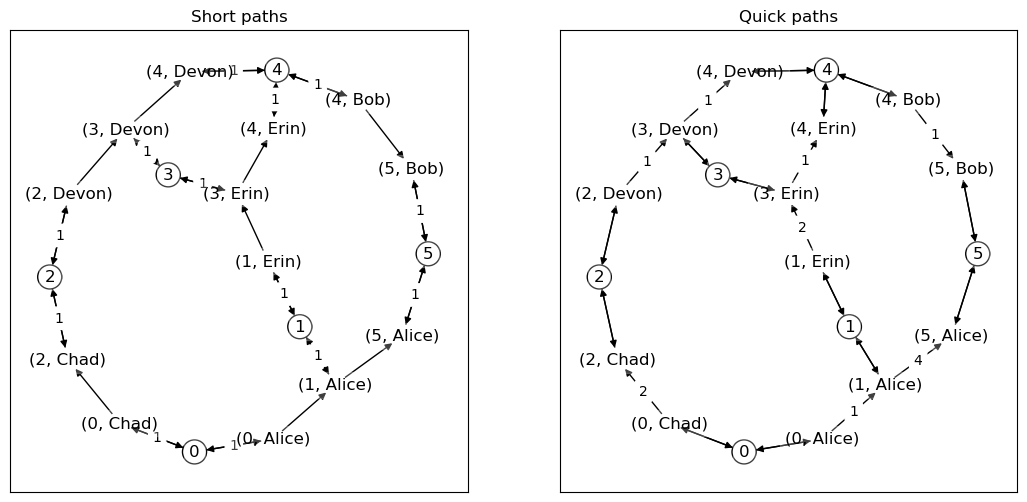

In [65]:
import networkx as nx
from hypernetx.drawing import temporal

from importlib import reload; reload(temporal)

plt.figure(figsize=(13, 6))
for i in (False, True):
    plt.subplot(1, 2, i + 1)
    plt.title('Quick paths' if i else 'Short paths')
    G = temporal.create_temporal_incidence_graph(H, edge_order=edge_order, weight_by_time=i)
    temporal.draw_temporal_incidence_graph(G)